libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent


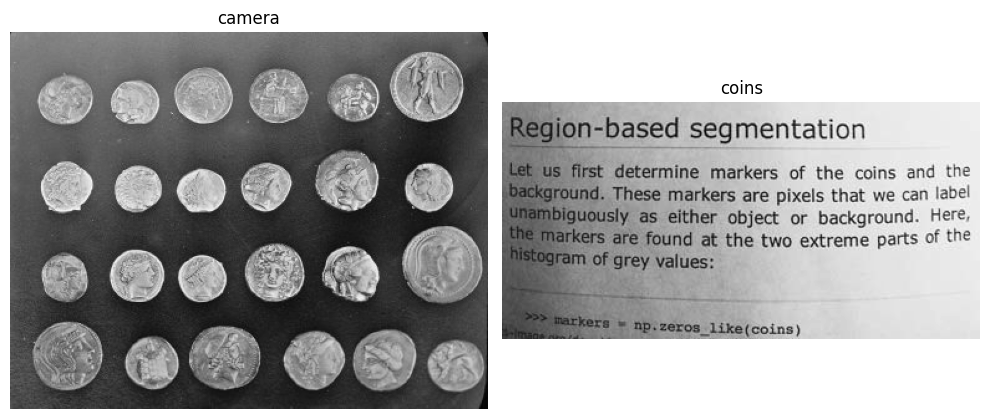

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

%matplotlib inline

# Read in the image
image = cv2.imread('/Users/charlottexx/Downloads/coins.png')
image1 = cv2.imread('/Users/charlottexx/Downloads/page.png')

# Change color to RGB (from BGR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)

# image = cv2.imread('image/page.png')
# image = cv2.imread('image/rocksample.png')

fig, axes = plt.subplots(1, 2, figsize=(10, 5)) 

axes[0].imshow(image, cmap='gray')  
axes[0].set_title('camera')  
axes[0].axis('off')  

axes[1].imshow(image1, cmap='gray')  
axes[1].set_title('coins')  
axes[1].axis('off')  

plt.tight_layout()
plt.show()


k = 2


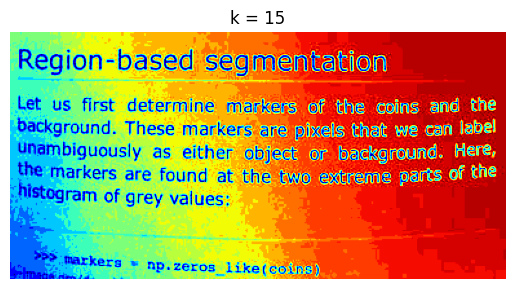

In [7]:
#https://www.geeksforgeeks.org/image-segmentation-using-k-means-clustering/

k=15
# Reshaping the image into a 2D array of pixels and 3 color values (RGB)
pixel_vals = image1.reshape((-1))

# Convert to float type
pixel_vals = np.float32(pixel_vals)
#the below line of code defines the criteria for the algorithm to stop running, 
#which will happen is 100 iterations are run or the epsilon (which is the required accuracy) 
#becomes 85%
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.9)

# then perform k-means clustering with number of clusters defined as 3
#also random centres are initially choosed for k-means clustering
retval, labels, centers = cv2.kmeans(pixel_vals,k, None, criteria, 20, cv2.KMEANS_RANDOM_CENTERS)

# convert data into 8-bit values
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]

# reshape data into the original image dimensions
segmented_image = segmented_data.reshape((image1.shape))

plt.imshow(segmented_image, cmap='jet')
plt.axis('off');
plt.title(f'k = {k}')
plt.savefig("k-means.png", bbox_inches='tight', dpi=300) 

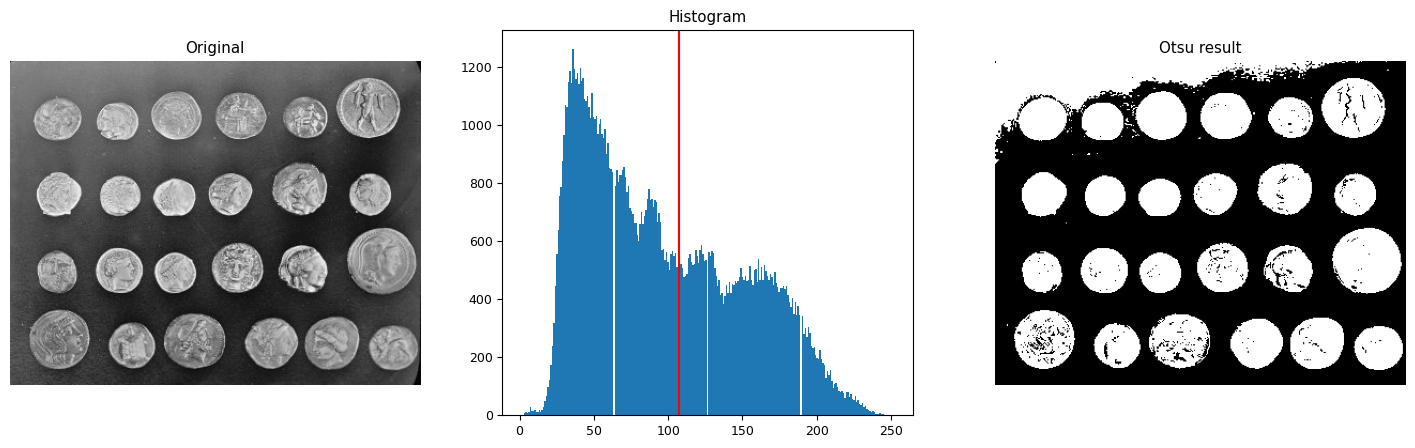

In [14]:
#https://scikit-image.org/docs/0.24.x/auto_examples/segmentation/plot_multiotsu.html

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage.filters import threshold_multiotsu

# Setting the font size for all plots.
matplotlib.rcParams['font.size'] = 9

# Applying multi-Otsu threshold for the default value, generating
# three classes.
thresholds = threshold_multiotsu(image, classes=k)

# Using the threshold values, we generate the three regions.
regions = np.digitize(image, bins=thresholds)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# Plotting the original image.
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Plotting the histogram and the two thresholds obtained from
# multi-Otsu.
ax[1].hist(image.ravel(), bins=255)
ax[1].set_title('Histogram')
for thresh in thresholds:
    ax[1].axvline(thresh, color='r')

# Plotting the Multi Otsu result.
ax[2].imshow(regions, cmap='grey')
ax[2].set_title('Otsu result')
ax[2].axis('off')

plt.subplots_adjust()
plt.savefig("Otsu.png", bbox_inches='tight', dpi=300) 
plt.show()


Otsu Threshold: 87
Multi-Otsu Threshold (k=2): [87]


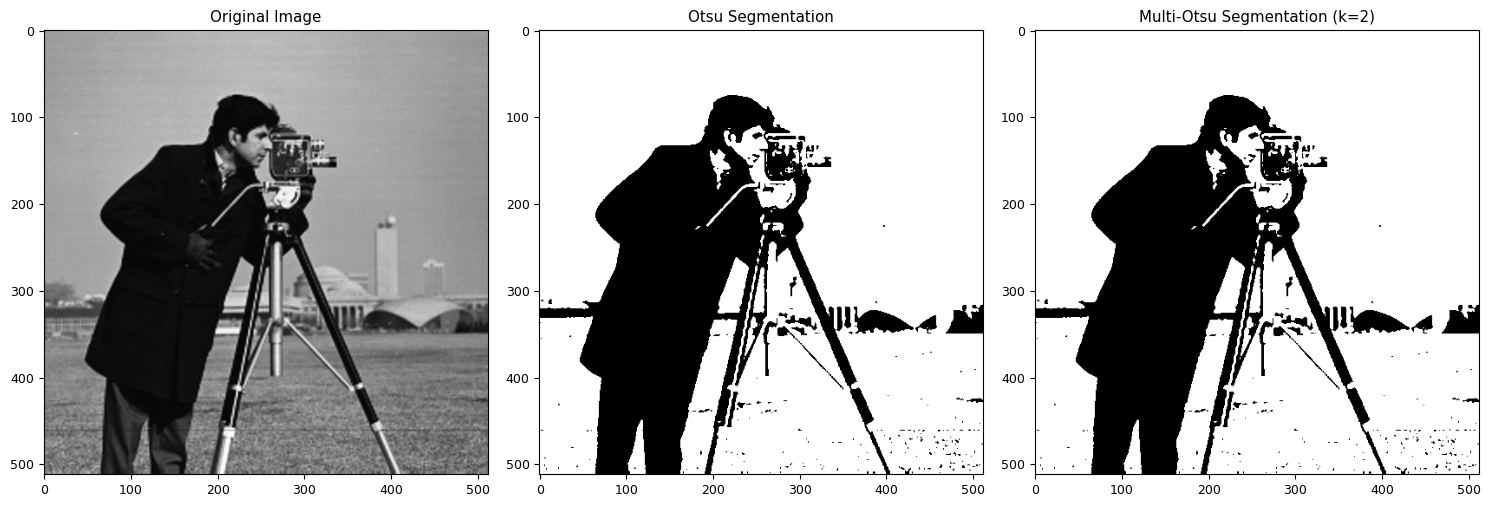

In [120]:
from skimage.filters import threshold_otsu, threshold_multiotsu
import numpy as np
import matplotlib.pyplot as plt

# 假设 `image` 是输入灰度图像
otsu_threshold = threshold_otsu(image)
multiotsu_thresholds = threshold_multiotsu(image, classes=2)

print(f"Otsu Threshold: {otsu_threshold}")
print(f"Multi-Otsu Threshold (k=2): {multiotsu_thresholds}")

# 单一阈值分割
otsu_segmented = image > otsu_threshold

# Multi-Otsu 分割
multiotsu_segmented = image > multiotsu_thresholds[0]

# 可视化分割结果
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')

axes[1].imshow(otsu_segmented, cmap='gray')
axes[1].set_title('Otsu Segmentation')

axes[2].imshow(multiotsu_segmented, cmap='gray')
axes[2].set_title('Multi-Otsu Segmentation (k=2)')

plt.tight_layout()
plt.show()

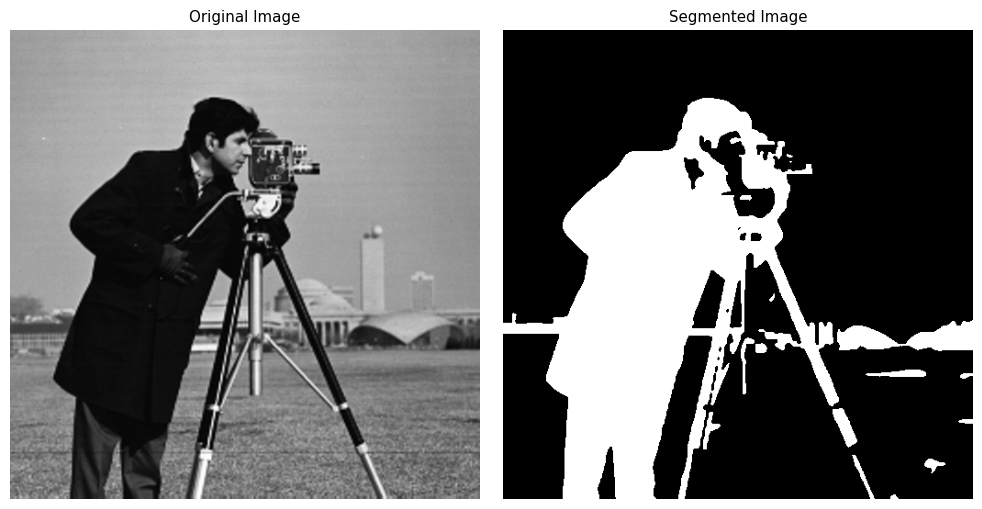

In [199]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.segmentation import chan_vese


# Apply Chan-Vese segmentation
cv_result = chan_vese(image, mu=0.25, lambda1=1, lambda2=1, tol=1e-3, dt=0.5, init_level_set="checkerboard", extended_output=True)

# Extract the segmented image
segmented_image = cv_result[0]

# Plot the original and segmented images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ax = axes.flatten()

ax[0].imshow(image, cmap="gray")
ax[0].set_title("Original Image")

ax[1].imshow(segmented_image, cmap="gray")
ax[1].set_title("Segmented Image")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

In [197]:
foreground_values = image[segmented_image == 1]  # 前景（白色部分）
background_values = image[segmented_image == 0]  # 背景（黑色部分）

# 计算灰度值的均值
foreground_mean = np.mean(foreground_values)
background_mean = np.mean(background_values)

print(f"Foreground mean grayscale value: {foreground_mean}")
print(f"Background mean grayscale value: {background_mean}")

Foreground mean grayscale value: 25.96055704037136
Background mean grayscale value: 152.6781433521413


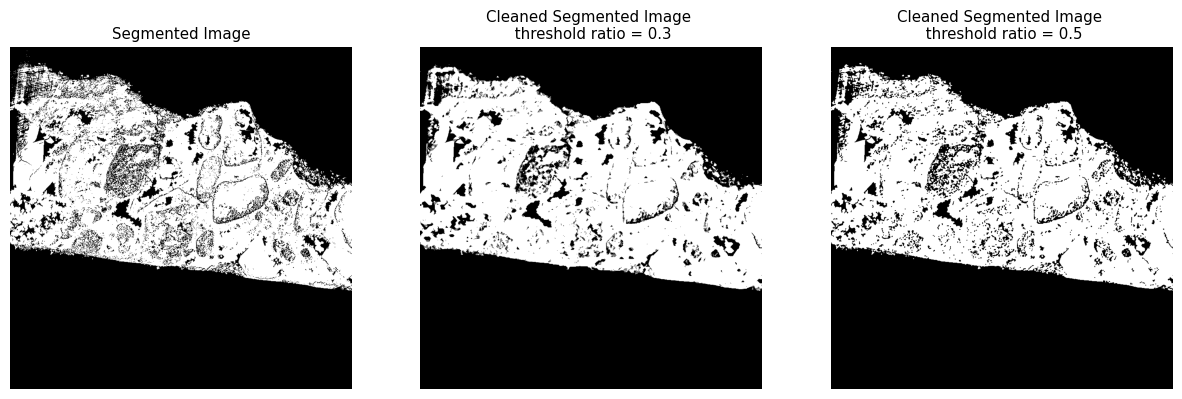

In [15]:
def denoise_segmentation(segmented_image, threshold_ratio=0.66, n_neighbours=8):
    # Get the dimensions of the image
    rows, cols = segmented_image.shape
    
    # Create a copy of the segmented image to store the cleaned segmentation
    cleaned_image = segmented_image.copy()
    
    # Define the 8 possible neighbors (relative positions)
    if n_neighbours == 4:
        neighbors = [(-1, 0), (0, -1), (0, 1), (1, 0)]
    else:
        neighbors = [(-1, -1), (-1, 0), (-1, 1), 
                    (0, -1),         (0, 1), 
                    (1, -1), (1, 0), (1, 1)]
        
    # Iterate over each pixel in the image (excluding the border pixels)
    for i in range(1, rows-1):
        for j in range(1, cols-1):
            # Get the current pixel label
            current_label = segmented_image[i, j]
            
            # Count the votes for each label among the neighbors
            votes = {}
            for dx, dy in neighbors:
                neighbor_label = segmented_image[i + dx, j + dy]
                if neighbor_label in votes:
                    votes[neighbor_label] += 1
                else:
                    votes[neighbor_label] = 1
            
            # Determine the majority label based on the threshold ratio
            max_votes = max(votes.values())
            majority_label = max(votes, key=votes.get)
            if max_votes >= threshold_ratio * len(neighbors):
                cleaned_image[i, j] = majority_label
    
    return cleaned_image

def repeated_denoise_segmentation(segmented_image, threshold_ratio=0.66, n_iter=5, n_neighbours=8):
    # Apply the denoising algorithm iteratively
    cleaned_image = segmented_image.copy()
    for _ in range(n_iter):
        cleaned_image = denoise_segmentation(cleaned_image, threshold_ratio, n_neighbours)
    
    return cleaned_image 

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 8))


# Apply the denoising algorithm to the segmented image
cleaned_segmented_image1 = repeated_denoise_segmentation(segmented_image, threshold_ratio=0.3, n_iter=5, n_neighbours=4)
cleaned_segmented_image2 = repeated_denoise_segmentation(segmented_image, threshold_ratio=0.55, n_iter=5, n_neighbours=4)
cleaned_segmented_image3 = repeated_denoise_segmentation(segmented_image, threshold_ratio=0.66, n_iter=10, n_neighbours=4)
cleaned_segmented_image4 = repeated_denoise_segmentation(segmented_image, threshold_ratio=0.9, n_iter=10, n_neighbours=4)

ax[0].imshow(segmented_image, cmap='gray')
ax[0].set_title('Segmented Image')
ax[0].axis('off')

# Plot the cleaned segmented image
ax[1].imshow(cleaned_segmented_image1, cmap='gray')
ax[1].set_title('Cleaned Segmented Image \n threshold ratio = 0.3')
ax[1].axis('off')

ax[2].imshow(cleaned_segmented_image2, cmap='gray')
ax[2].set_title('Cleaned Segmented Image \n threshold ratio = 0.5')
ax[2].axis('off')

plt.show()

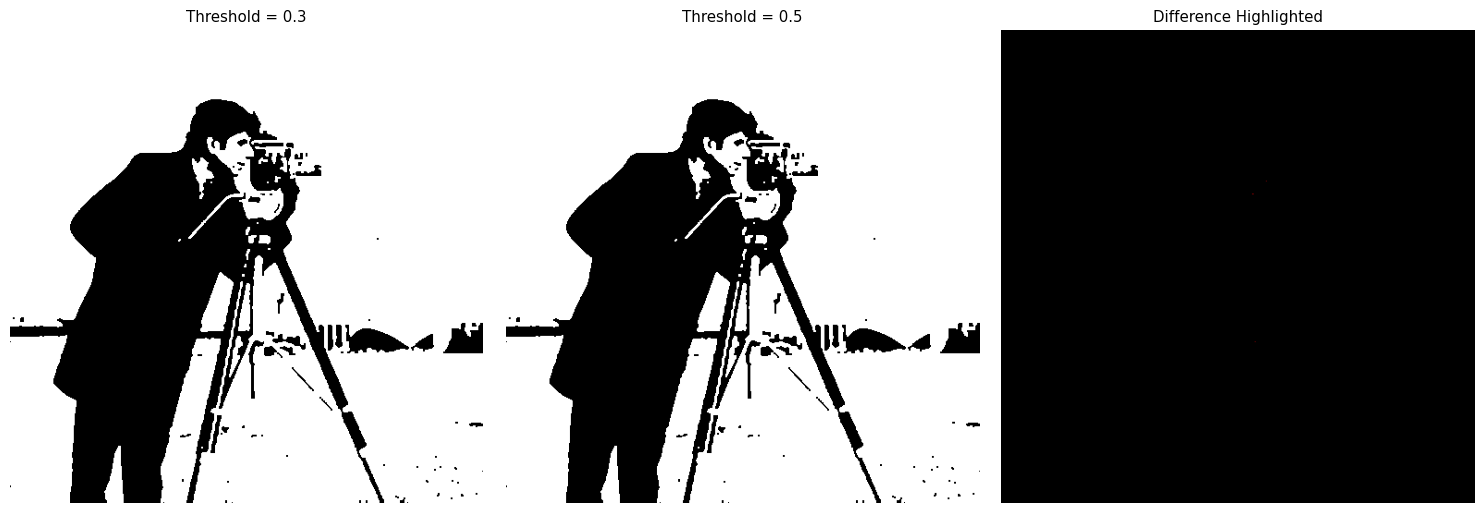

In [158]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# 找到两张图片的差异
difference = cv2.absdiff(cleaned_segmented_image2, cleaned_segmented_image3)

# 标记差异（将差异高亮显示，例如红色）
highlighted_difference = cv2.merge((difference, np.zeros_like(difference), np.zeros_like(difference)))

# 显示对比图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cleaned_segmented_image2, cmap='gray')
ax[0].set_title("Threshold = 0.3")
ax[0].axis('off')

ax[1].imshow(cleaned_segmented_image3, cmap='gray')
ax[1].set_title("Threshold = 0.5")
ax[1].axis('off')

ax[2].imshow(highlighted_difference)
ax[2].set_title("Difference Highlighted")
ax[2].axis('off')

plt.tight_layout()
plt.show()


In [159]:
num_differences = np.sum(difference > 0)
print(f"Number of differing pixels: {num_differences}")


Number of differing pixels: 4
